<div style="padding: 60px;
  text-align: center;
  background: #7dc8ca;
  color: #003049;
  font-size: 20px;">
  <h2>Inclass: Unsupervised Learning</h2>
   <hr>
</div>


- **This notebook based on main material**
- **Course Length**: 6 hours
- **Instructor** : Dyah Nurlita
- **Last Updated**: October 2025

## Training Objectives

This coursebook is intended for participants who have completed the preceding courses. 

The coursebook focuses on:

* **Introduction to Unsupervised Learning**
    * Supervised vs Unsupervised Learning
* **K-Means Clustering**
    * Understanding and Practicing K-Means
    * Optimal Number of Cluster
* **K-Medoids Clustering**
    * Understanding and Practicing K-Medoids
    * Choosing Right Clustering Method based on Data

# 🤖 Introduction to Unsupervised Learning

Machine Learning terbagi menjadi dua jenis utama: **Supervised Learning** dan **Unsupervised Learning**. Untuk memahami posisi *unsupervised learning*, mari kita bandingkan dulu dengan supervised learning.

## 🎯 Supervised vs Unsupervised Learning

* **Supervised Learning**

  * Ada **label/target** (misalnya: apakah email itu *spam* atau *bukan spam*).
  * Tujuan: melatih model agar bisa memprediksi label baru berdasarkan data yang belum pernah dilihat.

* **Unsupervised Learning**

  * **Tidak ada target/label**.
  * Tujuan: menemukan pola atau struktur tersembunyi dalam data.
  * Contoh: mengelompokkan pelanggan berdasarkan kebiasaan belanja, tanpa tahu sebelumnya kelompok apa yang ada.

👉 Singkatnya:

* **Supervised** → ada label, belajar dengan “jawaban”.
* **Unsupervised** → tidak ada label, belajar mencari pola sendiri.

---

## 🔍 Unsupervised Learning

**Karakteristik utama:**

* ❌ Tidak memiliki target variabel.
* 🧩 Digunakan untuk menemukan pola atau struktur dalam data.
* 📊 Umumnya dipakai pada tahap **Exploratory Data Analysis (EDA)** atau **pre-processing**.
* 🤔 Evaluasi lebih sulit, karena tidak ada *ground truth*.

**Contoh penerapan:**

* *Clustering*: Mengelompokkan pelanggan, dokumen, atau gambar.
* *Dimensionality Reduction*: Seperti PCA (Principal Component Analysis), untuk menyederhanakan data tanpa kehilangan informasi penting.

Dalam modul ini, kita akan fokus pada metode **Clustering**:

* K-Means Clustering
* K-Medoids Clustering

Keduanya banyak digunakan di dunia nyata, khususnya untuk segmentasi data.



In [1]:
import importlib
from pylab import rcParams
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# for data manipulation
import pandas as pd 
pd.set_option('display.float_format', lambda x: '%.3f' % x) # suppress scientific notation
pd.set_option('display.max_columns', None) # display all columns

# for matrix-based computation
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as colors

# Scalers
from sklearn.preprocessing import StandardScaler

# clustering
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn_extra.cluster import KMedoids

# Gower matrix
import gower as go

# custom functions
from helper import plot_elbow_kmeans, plot_elbow_kmedoids, plot_depth_readings_cluster, biplot_kmeans

%matplotlib inline

In [2]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

## 🛢️ Study Case: Clustering on Well Logging Data

Dalam industri minyak dan gas, **sumur** adalah komponen utama untuk mengekstraksi sumber daya dari bawah permukaan bumi. Saat pengeboran berlangsung, perusahaan perlu menentukan apakah sumur yang sedang digali benar-benar mengandung minyak atau gas yang bernilai ekonomi.

Salah satu cara untuk mengetahuinya adalah melalui **well logging** — yaitu memasukkan alat logging ke dalam sumur untuk mengukur berbagai sifat batuan pada kedalaman tertentu.

![](assets/well_logging.jpg)

### 🔧 Apa itu Well Logging?

* Struktur alat logging menyerupai pipa dengan berbagai sensor di dalamnya.
* Setiap sensor menghasilkan **data pengukuran** (misalnya resistivitas, densitas, porositas).
* Data ini kemudian dianalisis oleh geologis untuk menilai apakah pengeboran layak dilanjutkan ke tahap berikutnya: **well completion** (penyelesaian sumur agar siap berproduksi).

> 👉 Intinya, well logging membantu menjawab: *“Apakah batuan di sekitar sumur ini mengandung cukup minyak/gas?”*


### 📊 Dataset yang Digunakan

Untuk latihan, kita akan menggunakan dataset dari **[FORCE 2020 Well log and lithofacies dataset for machine learning competition](https://zenodo.org/records/4351156)**.

* Dataset ini berisi data logging dari **118 sumur di Laut Norwegia**.
* Data ini sebelumnya digunakan untuk kompetisi ML dengan tujuan memprediksi litofasies (jenis lapisan batuan) berdasarkan data seismik dan logging.
* Banyak nilai **missing value** ditemukan di dataset asli. Untuk modul ini, kita sudah melakukan:

  * Prapemrosesan
  * Sampling data dari sumur **ID `25/2-7`**
  * Mengganti nilai hilang dengan `0` atau nilai statistik lain.


### 🎯 Tujuan Analisis

Dalam kasus ini, kita ingin menjawab pertanyaan berikut:

1. Apakah sumur yang sedang digali memiliki **potensi penambangan** yang cukup?
2. Karakteristik atau variabel apa yang paling berpengaruh terhadap potensi tersebut?
3. Bisakah kita mengelompokkan jenis batuan (**lithologi**) hanya dari data alat logging?

💡 Metode yang digunakan: **Clustering**.

### 1. 📂 Load Data

In [3]:
# load data
well_2527 = pd.read_csv('data_input/train_well_25_2_7_sampled.csv')

# 5 first observations
well_2527.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LITHOLOGY_CLASS_CONFIDENCE
0,25/2-7,204.594,479890.531,6641111.500,-179.591,NORDLAND GP.,Vaale Fm.,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,2
1,25/2-7,206.722,479890.531,6641111.500,-181.719,NORDLAND GP.,Vaale Fm.,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,2
2,25/2-7,208.850,479890.531,6641111.500,-183.847,NORDLAND GP.,Vaale Fm.,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,1
3,25/2-7,212.802,479890.531,6641111.500,-187.799,NORDLAND GP.,Vaale Fm.,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Sandstone/Shale,1
4,25/2-7,212.954,479890.531,6641111.500,-187.951,NORDLAND GP.,Vaale Fm.,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,Sandstone/Shale,1


#### **📑 Deskripsi Variabel pada Well Logging Data**

Dataset ini terdiri dari beberapa kelompok kolom:

**🗂️ Metadata Columns**

* `WELL` → Nama sumur.
* `DEPTH_MD` → Kedalaman pengeboran yang diukur (*measured depth*, dalam meter).
* `X_LOC` → Koordinat X (UTM).
* `Y_LOC` → Koordinat Y (UTM).
* `Z_LOC` → Kedalaman (meter).
* `GROUP` → Grup litostratigrafi menurut NPD.
* `FORMATION` → Formasi litostratigrafi menurut NPD.

**📉 Well Log Curves (hasil pengukuran alat logging)**

* `BS` → Borehole size (inch).
* `CALI` → Caliper log (inch).
* `RHOB` → Bulk density log (g/cm³).
* `GR` → Gamma ray log (satuan API).
* `SGR` → Spectra gamma ray log (satuan API).
* `ROP` → Rate of penetration (m/h).
* `NPHI` → Neutron porosity log (fraksi → bisa ditafsirkan dalam persen).
* `PEF` → Photoelectric absorption factor log (barns/electron).
* `RSHA` → Shallow resistivity measurement (Ω·m).
* `RMED` → Medium resistivity measurement (Ω·m).
* `RDEP` → Deep resistivity measurement (Ω·m).
* `DTS` → Shear wave sonic log (µs/ft).
* `DTC` → Compressional wave sonic log (µs/ft).

**🏷️ Interpretation Columns**

* `LITHOFACIES_CLASS` → Label litologi (dari interpretasi ahli geologi).
* `LITHOFACIES_CLASS_CONFIDENCE` → Tingkat kepercayaan interpretasi (1 = tinggi, 2 = sedang, 3 = rendah).

> 💡 **Catatan penting:**
> 
> Walaupun dataset sudah memiliki kolom label (`LITHOFACIES_CLASS`), tujuan kita adalah **menggunakan unsupervised learning** untuk mengelompokkan litofasies berdasarkan data logging. Nantinya, hasil cluster bisa dibandingkan dengan label asli untuk evaluasi.

### 2. Mempersiapkan Data

Dalam proses persiapan data, ada beberapa langkah yang akan dilakukan untuk memastikan data kita siap untuk dimodelkan. Beberapa langkah ini termasuk melihat informasi dalam data, memeriksa nilai yang hilang, dan mengidentifikasi duplikat.

In [4]:
# the information in the data
well_2527.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 29 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   WELL                        2500 non-null   object 
 1   DEPTH_MD                    2500 non-null   float64
 2   X_LOC                       2500 non-null   float64
 3   Y_LOC                       2500 non-null   float64
 4   Z_LOC                       2500 non-null   float64
 5   GROUP                       2500 non-null   object 
 6   FORMATION                   2500 non-null   object 
 7   CALI                        2500 non-null   float64
 8   RSHA                        2500 non-null   float64
 9   RMED                        2500 non-null   float64
 10  RDEP                        2500 non-null   float64
 11  RHOB                        2500 non-null   float64
 12  GR                          2500 non-null   float64
 13  SGR                         2500 

In [5]:
# check for missing values
well_2527.isna().sum()

WELL                          0
DEPTH_MD                      0
X_LOC                         0
Y_LOC                         0
Z_LOC                         0
GROUP                         0
FORMATION                     0
CALI                          0
RSHA                          0
RMED                          0
RDEP                          0
RHOB                          0
GR                            0
SGR                           0
NPHI                          0
PEF                           0
DTC                           0
SP                            0
BS                            0
ROP                           0
DTS                           0
DCAL                          0
DRHO                          0
MUDWEIGHT                     0
RMIC                          0
ROPA                          0
RXO                           0
LITHOLOGY_CLASS               0
LITHOLOGY_CLASS_CONFIDENCE    0
dtype: int64

In [6]:
# check for duplicates
well_2527.duplicated().sum()

0

> Insight: 

### 3. ⚙️ Data Preprocessing

Sebelum kita melakukan clustering, data perlu dipersiapkan agar siap dimodelkan. Ada beberapa langkah utama:

1. **Pilih kolom numerik** → hanya variabel log hasil pengukuran yang bertipe numerik.
2. **Scaling/Standarisasi** → menyamakan rentang nilai, karena tiap variabel punya skala berbeda (misalnya `GR` dalam API vs `RHOB` dalam g/cm³).
3. **Pemeriksaan data** → pastikan tidak ada duplikat, nilai yang hilang sudah ditangani, dan format sesuai.

#### 🔢 Memilih Kolom Numerik

Kita mulai dengan memfilter hanya variabel numerik yang relevan untuk clustering.

In [7]:
well_2527.head()

,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,GROUP,FORMATION,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LITHOLOGY_CLASS_CONFIDENCE
0,25/2-7,204.594,479890.531,6641111.500,-179.591,NORDLAND GP.,Vaale Fm.,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,2
1,25/2-7,206.722,479890.531,6641111.500,-181.719,NORDLAND GP.,Vaale Fm.,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,2
2,25/2-7,208.850,479890.531,6641111.500,-183.847,NORDLAND GP.,Vaale Fm.,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,1
3,25/2-7,212.802,479890.531,6641111.500,-187.799,NORDLAND GP.,Vaale Fm.,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Sandstone/Shale,1
4,25/2-7,212.954,479890.531,6641111.500,-187.951,NORDLAND GP.,Vaale Fm.,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,Sandstone/Shale,1


In [8]:
# cek persebaran data dengan describe()
well_2527.describe()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS_CONFIDENCE
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,2148.903,479870.802,6641104.362,-2123.592,15.641,5.554,5.396,4.481,2.215,54.589,0.000,0.132,3.621,116.027,50.112,14.228,1.247,0.000,0.000,0.033,0.054,0.000,0.000,2.201,1.084
std,1094.089,17.927,10.450,1093.789,4.152,27.701,31.654,21.947,0.260,35.368,0.000,0.159,1.555,31.527,15.683,3.621,2.517,0.000,0.000,0.069,0.066,0.000,0.000,19.713,0.311
min,204.594,479837.625,6641080.500,-3993.574,8.141,0.374,0.374,0.333,1.412,9.025,0.000,0.000,0.831,55.657,12.937,8.500,0.000,0.000,0.000,-0.037,0.000,0.000,0.000,0.000,1.000
25%,1235.800,479854.117,6641097.000,-3076.047,12.500,0.808,0.808,0.902,2.031,31.890,0.000,0.000,2.525,86.294,38.802,12.250,0.000,0.000,0.000,-0.004,0.000,0.000,0.000,0.000,1.000
50%,2146.850,479876.766,6641111.000,-2121.697,17.949,1.351,1.351,1.436,2.135,47.967,0.000,0.000,3.290,120.642,46.191,17.500,0.000,0.000,0.000,0.005,0.000,0.000,0.000,0.000,1.000
75%,3101.638,479887.781,6641113.000,-1210.778,18.531,3.654,3.617,3.309,2.441,64.602,0.000,0.276,4.513,145.319,60.981,17.500,1.271,0.000,0.000,0.040,0.132,0.000,0.000,0.000,1.000
max,4019.490,479890.531,6641114.000,-179.591,24.031,834.524,1196.175,758.366,2.959,710.987,0.000,0.636,12.085,166.920,94.045,17.500,27.710,0.000,0.000,0.416,0.147,0.000,0.000,463.578,3.000


In [9]:
# 🔎 Pilih kolom numerik dari dataset
well_num = well_2527.select_dtypes(['float64','int64'])
well_num.head()

,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS_CONFIDENCE
0,204.594,479890.531,6641111.500,-179.591,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,2
1,206.722,479890.531,6641111.500,-181.719,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,2
2,208.850,479890.531,6641111.500,-183.847,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,1
3,212.802,479890.531,6641111.500,-187.799,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1
4,212.954,479890.531,6641111.500,-187.951,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,1


In [10]:
# Cek dimensi data hasil filter
print("Dimensi data numerik:", well_num.shape)

Dimensi data numerik: (2500, 25)


<u>**Memilih kolom yang relevan**</u>

In [11]:
well_num.columns

Index(['DEPTH_MD', 'X_LOC', 'Y_LOC', 'Z_LOC', 'CALI', 'RSHA', 'RMED', 'RDEP',
       'RHOB', 'GR', 'SGR', 'NPHI', 'PEF', 'DTC', 'SP', 'BS', 'ROP', 'DTS',
       'DCAL', 'DRHO', 'MUDWEIGHT', 'RMIC', 'ROPA', 'RXO',
       'LITHOLOGY_CLASS_CONFIDENCE'],
      dtype='object')

In [12]:
# pilih kolom yang relevan untuk pemodelan
well_num_selected = well_num.drop(columns=['X_LOC','Y_LOC','Z_LOC','LITHOLOGY_CLASS_CONFIDENCE'])
well_num_selected.head()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
0,204.594,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000
1,206.722,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000
2,208.850,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000
3,212.802,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000
4,212.954,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000


#### ⚖️ Melakukan Scaling

🔎 Kenapa Scaling Penting?

Tujuan scaling adalah **menyamakan rentang nilai antar variabel** agar tidak ada variabel tertentu yang mendominasi analisis hanya karena skalanya lebih besar.

* **Variance dan covariance dipengaruhi skala data.**
  Misalnya, `DEPTH_MD` (kedalaman dalam meter) bisa bernilai ribuan, sedangkan `NPHI` (porositas) hanya bernilai 0–1.
* Jika tidak di-scale, variabel berskala besar akan memberikan kontribusi berlebih pada analisis seperti **clustering**.

In [13]:
# Mengecek rentang nilai tiap kolom
well_num_selected.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,2148.903,15.641,5.554,5.396,4.481,2.215,54.589,0.000,0.132,3.621,116.027,50.112,14.228,1.247,0.000,0.000,0.033,0.054,0.000,0.000,2.201
std,1094.089,4.152,27.701,31.654,21.947,0.260,35.368,0.000,0.159,1.555,31.527,15.683,3.621,2.517,0.000,0.000,0.069,0.066,0.000,0.000,19.713
min,204.594,8.141,0.374,0.374,0.333,1.412,9.025,0.000,0.000,0.831,55.657,12.937,8.500,0.000,0.000,0.000,-0.037,0.000,0.000,0.000,0.000
25%,1235.800,12.500,0.808,0.808,0.902,2.031,31.890,0.000,0.000,2.525,86.294,38.802,12.250,0.000,0.000,0.000,-0.004,0.000,0.000,0.000,0.000
50%,2146.850,17.949,1.351,1.351,1.436,2.135,47.967,0.000,0.000,3.290,120.642,46.191,17.500,0.000,0.000,0.000,0.005,0.000,0.000,0.000,0.000
75%,3101.638,18.531,3.654,3.617,3.309,2.441,64.602,0.000,0.276,4.513,145.319,60.981,17.500,1.271,0.000,0.000,0.040,0.132,0.000,0.000,0.000
max,4019.490,24.031,834.524,1196.175,758.366,2.959,710.987,0.000,0.636,12.085,166.920,94.045,17.500,27.710,0.000,0.000,0.416,0.147,0.000,0.000,463.578


> ......

#### ⚙️ Implementasi StandardScaler

Kita gunakan `StandardScaler` dari scikit-learn.

* **`fit()`** → menghitung mean dan standard deviation.
* **`transform()`** → menstandardisasi data.
* **`fit_transform()`** → menggabungkan keduanya dalam satu langkah.

In [14]:
# Import library
from sklearn.preprocessing import StandardScaler

# Copy data numerik
well_num_scaled = well_num_selected.copy()

# Ambil nama kolom numerik
cols = well_num_selected.columns

# Buat objek scaler
scaler = StandardScaler()

# Fit dan transformasi sekaligus
well_num_scaled[cols] = scaler.fit_transform(well_num_scaled[cols])

In [15]:
well_num_scaled.head()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
0,-1.777,1.340,-0.116,-0.096,-0.045,-0.437,0.123,0.000,-0.835,-0.891,0.184,-1.535,0.904,-0.495,0.000,0.000,0.052,-0.819,0.000,0.000,-0.112
1,-1.776,0.787,-0.104,-0.086,-0.041,0.029,0.240,0.000,-0.835,-0.852,0.952,-1.263,0.904,-0.495,0.000,0.000,-0.378,-0.819,0.000,0.000,-0.112
2,-1.774,0.758,-0.104,-0.086,-0.039,-0.020,0.224,0.000,-0.835,-0.894,0.960,-1.177,0.904,0.974,0.000,0.000,-0.397,-0.819,0.000,0.000,-0.112
3,-1.770,0.900,-0.121,-0.101,-0.073,-0.221,0.247,0.000,-0.835,-0.895,1.165,-1.256,0.904,0.083,0.000,0.000,-0.484,-0.819,0.000,0.000,-0.112
4,-1.770,0.921,-0.121,-0.101,-0.074,-0.227,0.182,0.000,-0.835,-0.919,1.170,-1.272,0.904,0.044,0.000,0.000,-0.493,-0.819,0.000,0.000,-0.112


In [16]:
# Cek hasil setelah scaling
well_num_scaled.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000
min,-1.777,-1.806,-0.187,-0.159,-0.189,-3.093,-1.289,0.000,-0.835,-1.795,-1.915,-2.371,-1.582,-0.495,0.000,0.000,-1.024,-0.819,0.000,0.000,-0.112
25%,-0.835,-0.756,-0.171,-0.145,-0.163,-0.709,-0.642,0.000,-0.835,-0.706,-0.943,-0.721,-0.546,-0.495,0.000,0.000,-0.538,-0.819,0.000,0.000,-0.112
50%,-0.002,0.556,-0.152,-0.128,-0.139,-0.307,-0.187,0.000,-0.835,-0.213,0.146,-0.250,0.904,-0.495,0.000,0.000,-0.410,-0.819,0.000,0.000,-0.112
75%,0.871,0.696,-0.069,-0.056,-0.053,0.868,0.283,0.000,0.903,0.574,0.929,0.693,0.904,0.010,0.000,0.000,0.101,1.168,0.000,0.000,-0.112
max,1.710,2.021,29.932,37.626,34.358,2.864,18.563,0.000,3.175,5.445,1.615,2.802,0.904,10.518,0.000,0.000,5.588,1.403,0.000,0.000,23.409


---

## 🧩 Clustering

Setelah data kita eksplorasi dan diproses, sekarang saatnya melakukan analisis lebih lanjut menggunakan **clustering**.

👉 **Clustering** adalah proses mengelompokkan data berdasarkan kemiripan karakteristiknya.

* Data dalam **satu cluster** → cenderung memiliki karakteristik yang mirip.
* Data dari **cluster berbeda** → cenderung memiliki karakteristik yang berbeda.

Ada banyak metode clustering, namun dalam modul ini kita akan fokus pada:

* **K-Means Clustering**
* **K-Medoids Clustering**

Keduanya sama-sama berbasis *centroid* (titik pusat), tetapi ada perbedaan dalam cara menentukan representasi cluster.

### 🔵 K-Means Clustering

#### 📖 Konsep Dasar

K-Means adalah salah satu algoritma clustering yang paling populer dan sederhana.

* Disebut *K-Means* karena jumlah cluster **K** ditentukan oleh pengguna, dan pusat cluster dihitung menggunakan **mean** dari anggota cluster.
* Termasuk kategori **centroid-based clustering algorithm** → artinya tiap cluster direpresentasikan oleh titik pusat (*centroid*).

#### ⚙️ Proses Algoritma K-Means

1. **Random Initialization**
   Meletakkan **K centroid** secara acak di ruang data.

2. **Cluster Assignment**
   Setiap observasi dialokasikan ke cluster terdekat, berdasarkan jarak (biasanya **Euclidean distance**).

   > Euclidean distance = jarak garis lurus antara dua titik.

3. **Centroid Update**
   Geser posisi centroid ke rata-rata (mean) dari seluruh anggota cluster tersebut.

4. **Repeat**
   Ulangi langkah 2 dan 3 hingga posisi centroid stabil (tidak banyak berubah) atau tidak ada observasi yang berpindah cluster lagi.

👉 Jumlah cluster **K** harus ditentukan sebelum menjalankan algoritma.

<img src="assets/kmeans.jpg" width="700">  

> 💡 **Tips Belajar**:
> Kalau masih bingung dengan konsep K-Means, coba lihat visualisasi interaktif di sini:
> 🔗 [Visualizing K-Means Clustering](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

### 🔄 K-Means Workflow

Proses penerapan **K-Means Clustering** biasanya melalui 4 tahap utama:

1. 🧹 **Persiapan Data**
2. 🔢 **Menentukan Nilai K**
3. 🏗️ **Membuat Cluster**
4. 🧭 **Cluster Profiling**

#### 1️⃣ Mempersiapkan Data

Pada tahap ini kita memastikan:

* Semua kolom yang dipakai sudah berupa **tipe data numerik**
* Data sudah melalui proses **scaling/standardisasi**

👉 Dua langkah ini sudah kita lakukan di bagian sebelumnya.

In [17]:
# Mengecek data
well_num_scaled.describe()

,DEPTH_MD,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO
count,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000,2500.000
mean,0.000,0.000,-0.000,0.000,-0.000,-0.000,0.000,0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,0.000,0.000,0.000,0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,0.000,0.000,1.000
min,-1.777,-1.806,-0.187,-0.159,-0.189,-3.093,-1.289,0.000,-0.835,-1.795,-1.915,-2.371,-1.582,-0.495,0.000,0.000,-1.024,-0.819,0.000,0.000,-0.112
25%,-0.835,-0.756,-0.171,-0.145,-0.163,-0.709,-0.642,0.000,-0.835,-0.706,-0.943,-0.721,-0.546,-0.495,0.000,0.000,-0.538,-0.819,0.000,0.000,-0.112
50%,-0.002,0.556,-0.152,-0.128,-0.139,-0.307,-0.187,0.000,-0.835,-0.213,0.146,-0.250,0.904,-0.495,0.000,0.000,-0.410,-0.819,0.000,0.000,-0.112
75%,0.871,0.696,-0.069,-0.056,-0.053,0.868,0.283,0.000,0.903,0.574,0.929,0.693,0.904,0.010,0.000,0.000,0.101,1.168,0.000,0.000,-0.112
max,1.710,2.021,29.932,37.626,34.358,2.864,18.563,0.000,3.175,5.445,1.615,2.802,0.904,10.518,0.000,0.000,5.588,1.403,0.000,0.000,23.409


#### 2️⃣ Menentukan Nilai `K`

Menentukan jumlah cluster (`k`) adalah bagian paling penting. Ada dua pendekatan:

**🔹 a. Berdasarkan Kebutuhan Bisnis**

* Jumlah cluster bisa ditentukan sesuai konteks bisnis atau tujuan analisis.
* Misalnya: pada kasus well logging, kita bisa mencoba menggunakan jumlah **kelas litologi unik** pada kolom `LITHOLOGY_CLASS`.
* Ini bisa menjadi *benchmark* untuk membandingkan apakah clustering mendekati hasil interpretasi geologis.

> **Catatan**: pada praktik unsupervised sebenarnya *ground truth* ini tidak selalu tersedia.

In [18]:
# cek jumlah nilai unik
well_2527['LITHOLOGY_CLASS'].unique()

array(['Sandstone/Shale', 'Sandstone', 'Shale', 'Coal', 'Limestone',
       'Dolomite', 'Tuff', 'Marl'], dtype=object)

In [19]:
well_2527['LITHOLOGY_CLASS'].nunique()

8

**🔹 b. Berdasarkan Metode Elbow**

* Jalankan K-Means dengan berbagai nilai `k`
* Plot hasil *within-cluster sum of squares (WCSS)*
* Pilih titik “patah” (elbow) → saat grafik mulai melandai.

📌 Untuk contoh awal, kita gunakan **pendekatan kebutuhan bisnis**.

#### 3️⃣ Modelling dengan `k = 8`

Misalnya, kita diminta membuat cluster **jenis batuan** dengan `k = 8`.
Kita bisa menggunakan fungsi `KMeans()` dari `sklearn.cluster`:

* `n_clusters=` → jumlah cluster yang ingin dibuat
* `random_state=` → angka pengunci agar hasil random konsisten

Seperti permodelan lainnya, fungsi `KMeans()` akan dilanjutkan dengan fungsi `.fit()` untuk melakukan pembuatan cluster dari data.

> Dokumentasi detail: [sklearn](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)

In [20]:
# Import Library
from sklearn.cluster import KMeans

In [21]:
# Buat model dengan k = 8
kmeans_lith8 = KMeans(n_clusters=8, random_state=123)

# Fit model ke data scaled
kmeans_lith8.fit(well_num_scaled)

KMeans(random_state=123)

#### 4️⃣ Melihat Hasil Cluster

Label cluster untuk setiap observasi bisa diperoleh dari atribut `.labels_`.

In [22]:
kmeans_lith8.labels_

array([0, 0, 0, ..., 5, 5, 5])

In [23]:
# Ambil label cluster
label8 = kmeans_lith8.labels_

# Tampilkan 30 label pertama
label8[:40]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

💡 **Insight:**

* .....
* .....

#### 📊 Hasil dan Evaluasi Cluster

Ingat kembali bahwa algoritma clustering masuk ke dalam algoritma **Unsupervised Learning**, sehingga tidak terdapat *ground truth* untuk hasil evaluasi modelnya.

⚖️ **Goodness of Fit** yang biasanya dipakai pada algoritma clustering yaitu:

* 🔹 **Evaluasi WSS (Within Sum of Square)**
  
  - Nilai ini menunjukkan kemiripan antar anggota pada cluster.
  - 👉 **Semakin kecil nilai WSS maka semakin baik**, karena mengindikasikan bahwa anggota pada cluster semakin mirip satu sama lain.

  - 📐 Rumus singkat:
    - `Hitung jarak tiap observasi ke centroid tiap cluster -> dikuadratkan -> dijumlahkan`
  - Untuk melihat nilai evaluasi WSS, kita akan menggunakan atributes `.inertia_` dari hasil pembuatan cluster.

In [24]:
WSS = kmeans_lith8.inertia_
print('WSS K Means:', WSS)

WSS K Means: 10270.855361706614


* 🔹 **Evaluasi BSS (Between Sum of Square)**
  - Nilai ini menunjukkan jarak antar centroid cluster.
  - 👉 **Semakin besar nilai BSS semakin baik**, karena mengindikasikan bahwa antar cluster memiliki karakteristik berbeda.
  - 📐 Rumus singkat:
    - `Hitung jarak centroid tiap cluster ke global sample mean -> dikuadratkan -> dikali jumlah data tiap cluster -> dijumlahkan`
  - `BCSS(data, object_cluster)`

In [25]:
# BSS
from helper import BCSS
bss_lith8 = BCSS(well_num_scaled.values, kmeans_lith8)

print('BSS K Means:', bss_lith8)

BSS K Means: 29722.907915262982


* 🔹 **Evaluasi TSS (Total Sum of Square)**
  Jarak tiap observasi ke global sample mean.
  
  Rumus:

  $$
  TSS = BSS + WSS
  $$

  Dari sini kita bisa hitung **Explained Variance (EV)** ✨
  
  👉 Semakin mendekati **100% semakin baik**, karena cluster semakin mewakili persebaran data.

  $$
  EV = \frac{BSS}{TSS} 
  $$

<!-- import numpy as np
import pandas as pd

def compute_tss(dataframe):
    # Step 1: Calculate the mean of the entire dataset
    mean_data = dataframe.mean()

    # Step 2: Compute the sum of squared distances
    tss = np.sum(np.linalg.norm(dataframe - mean_data, axis=1)**2)

    return tss

customer_scale.mean()

# Example usage:
# Replace 'your_data' with your actual dataset
your_data = customer_scale
tss_value = compute_tss(your_data)

print("Total Sum of Squares (TSS):", tss_value) -->

In [26]:
# TSS = BSS + WSS
tss_lith8 = bss_lith8 + WSS

print('TSS K Means:', tss_lith8)

TSS K Means: 39993.76327696959


In [27]:
# Explained variance
EV = bss_lith8/tss_lith8
print('Explained Variance K Means:', EV)

Explained Variance K Means: 0.7431885744140242


💡 **Insight** : Informasi yang berhasil ditangkap oleh 8 cluster adalah sebesar **74%**

---

#### 📉 Dari Evaluasi ke Pemilihan Nilai `k`

Sampai di tahap sebelumnya, kita sudah melakukan evaluasi hasil clustering menggunakan **WSS**, **BSS**, dan **Explained Variance (EV)**. Dari hasil itu, terlihat bahwa pemilihan jumlah cluster (`k`) memang sangat berpengaruh terhadap kualitas pemisahan data.

👉 Namun muncul pertanyaan:
Kalau begitu, **berapa jumlah cluster yang sebaiknya kita pilih?**

Jika kita hanya mengandalkan kebutuhan bisnis saja, memang seringkali ada angka yang jelas (misalnya 8 kelompok litologi). Tapi, dalam banyak kasus dunia nyata, kita **tidak selalu tahu berapa `k` yang ideal**.

Di sinilah kita butuh pendekatan objektif menggunakan **Elbow Plot**.


#### 📊 *Modelling* dengan Pemilihan `k` Optimum (*Elbow Plot*)

Semakin tinggi `k`:

* 🔽 WSS semakin mendekati 0
* 🔼 BSS semakin mendekati TSS (atau BSS/TSS mendekati 1)

Kalau begitu apakah kita selalu memilih `k = jumlah observasi`? 🤔


Tentu tidak. Ada 2 pertimbangan utama dalam menentukan nilai `k`:

1. 💼 **Kebutuhan bisnis** → misalnya jumlah segmen pelanggan, jenis litologi, atau kategori yang memang ingin dipetakan.
2. 📐 **Pendekatan objektif** → menggunakan metode *Elbow*, untuk mencari titik optimal.

Metode *Elbow* bekerja dengan cara memplot:

* Sumbu **X** → nilai `k` (jumlah cluster)
* Sumbu **Y** → nilai WSS (variansi dalam cluster)

🔎 Nilai `k` optimum terlihat pada titik "patah" (*elbow*) di mana penurunan WSS mulai melandai.

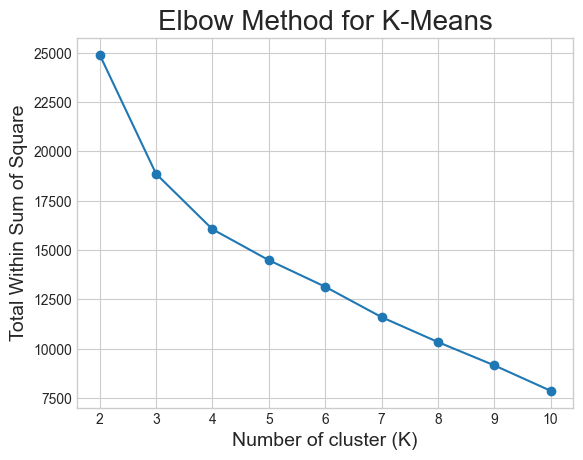

In [28]:
# Membuat visualisasi elbow untuk memilih k optimum
plot_elbow_kmeans(well_num_scaled)

👉 Pilih nilai `k` dengan kondisi: ketika `k` ditambah, **penurunan WSS tidak lagi signifikan** (garis mulai datar).

> 💡 Berdasarkan grafik elbow tersebut, manakah nilai `k` maksimum yang dapat dipilih? … cluster.

In [29]:
kmeans_lith4 = KMeans(n_clusters=4, random_state=123)

kmeans_lith4.fit(well_num_scaled)

KMeans(n_clusters=4, random_state=123)

In [32]:
kmeans_lith4.labels_

array([0, 0, 0, ..., 1, 1, 1])

**END OF DAY 1**

---

**START OF DAY 2**

### 🧩 *Cluster Profiling*

Tahap terakhir dari proses clustering adalah **profiling**, yaitu memahami karakteristik dari masing-masing cluster yang sudah terbentuk. Tujuan dari tahap ini adalah:

* 🔎 Mengetahui apa yang membedakan tiap cluster
* 📝 Memberi interpretasi praktis agar hasil clustering bisa dipakai dalam pengambilan keputusan

👉 Dalam konteks ini, kita akan mempelajari hasil cluster berdasarkan properti kedalaman dan pembacaan alat logging.

#### 📂 Menambahkan Label Cluster ke Data Asli

Pertama, mari kita salin kembali data asli lalu menambahkan label hasil clustering dari model *K-means*.

In [40]:
# Salin data tanpa kolom yang tidak diperlukan: 'GROUP','FORMATION','LITHOLOGY_CLASS_CONFIDENCE'
well_2527_copy = well_2527.copy().drop(columns=['GROUP','FORMATION','LITHOLOGY_CLASS_CONFIDENCE'])

Selanjutnya, kita akan menambahkan label dari model K-means sebelumnya ke dataframe `well_2527_copy`.

In [41]:
kmeans_lith8.labels_[0:40]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 3, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [42]:
# Assign label hasil K-means (k=8)
well_2527_copy['LABEL_K8'] = kmeans_lith8.labels_

In [43]:
# sanity check
well_2527_copy


,WELL,DEPTH_MD,X_LOC,Y_LOC,Z_LOC,CALI,RSHA,RMED,RDEP,RHOB,GR,SGR,NPHI,PEF,DTC,SP,BS,ROP,DTS,DCAL,DRHO,MUDWEIGHT,RMIC,ROPA,RXO,LITHOLOGY_CLASS,LABEL_K8
0,25/2-7,204.594,479890.531,6641111.500,-179.591,21.204,2.352,2.352,3.484,2.102,58.924,0.000,0.000,2.236,121.830,26.042,17.500,0.000,0.000,0.000,0.037,0.000,0.000,0.000,0.000,Sandstone/Shale,0
1,25/2-7,206.722,479890.531,6641111.500,-181.719,18.908,2.677,2.677,3.578,2.223,63.074,0.000,0.000,2.296,146.036,30.309,17.500,0.000,0.000,0.000,0.007,0.000,0.000,0.000,0.000,Sandstone/Shale,0
2,25/2-7,208.850,479890.531,6641111.500,-183.847,18.786,2.671,2.671,3.619,2.210,62.495,0.000,0.000,2.232,146.280,31.651,17.500,3.697,0.000,0.000,0.006,0.000,0.000,0.000,0.000,Sandstone/Shale,0
3,25/2-7,212.802,479890.531,6641111.500,-187.799,19.377,2.208,2.208,2.874,2.158,63.316,0.000,0.000,2.230,152.762,30.420,17.500,1.454,0.000,0.000,0.000,0.000,0.000,0.000,0.000,Sandstone/Shale,0
4,25/2-7,212.954,479890.531,6641111.500,-187.951,19.465,2.195,2.195,2.862,2.156,61.012,0.000,0.000,2.193,152.898,30.159,17.500,1.358,0.000,0.000,-0.001,0.000,0.000,0.000,0.000,Sandstone/Shale,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2495,25/2-7,4015.690,479837.719,6641081.000,-3989.777,9.899,4.568,4.568,3.667,2.586,94.123,0.000,0.264,4.813,84.304,92.971,8.500,0.000,0.000,0.000,0.349,0.000,0.000,0.000,0.000,Shale,5
2496,25/2-7,4016.906,479837.688,6641081.000,-3990.992,9.457,4.218,4.218,3.316,2.354,102.151,0.000,0.282,4.941,88.406,93.600,8.500,0.000,0.000,0.000,0.247,0.000,0.000,0.000,0.000,Shale,5
2497,25/2-7,4017.058,479837.688,6641081.000,-3991.144,9.459,4.174,4.174,3.307,2.429,100.566,0.000,0.278,5.023,88.783,93.718,8.500,0.000,0.000,0.000,0.275,0.000,0.000,0.000,0.000,Shale,5
2498,25/2-7,4018.730,479837.625,6641080.500,-3992.815,9.441,4.512,4.512,3.558,2.482,101.590,0.000,0.302,4.708,86.998,93.809,8.500,0.000,0.000,0.000,0.308,0.000,0.000,0.000,0.000,Shale,5


#### ⛏️ Profiling Berdasarkan Kedalaman (`DEPTH_MD`)


Selanjutnya, kita dapat melakukan profiling berdasarkan cluster yang terbentuk. Ada berbagai cara untuk melakukan hal ini. Sebagai contoh, kita dapat melakukan agregasi data berdasarkan cluster. Kita akan membuat profil cluster yang terbentuk dari model K-means dengan $k = 8$, yang diberi nama `kmeans_lith8`.

Kita bisa melihat **median kedalaman** untuk tiap cluster, lalu membandingkannya.

In [46]:
# 1st: look from depth
well_2527_copy[['DEPTH_MD','LABEL_K8']].groupby('LABEL_K8').median().sort_values(by='DEPTH_MD',ascending=True)

,DEPTH_MD
LABEL_K8,
4,905.086
0,1165.538
3,1584.906
6,2531.106
1,3146.402
2,3529.290
7,3558.626
5,3749.310


🔎 Dari hasil ini, kita bisa melihat cluster mana yang cenderung berada di dekat permukaan, dan mana yang berada lebih dalam.

> Insight:
>
> * cluster 4 paling dangkal
> * cluster 5 paling dalam

#### 🛢️ Profiling Berdasarkan Porositas Neutron (NPHI)

Selanjutnya, mari kita analisis cluster berdasarkan nilai `NPHI` (Neutron Porosity). Variabel ini penting untuk mengukur **kandungan hidrogen**, yang sering digunakan sebagai indikator adanya minyak atau gas.

In [51]:
# 2st: look from neutron porosity
well_2527_copy[['DEPTH_MD','NPHI','LABEL_K8']].groupby('LABEL_K8').median().sort_values(by='DEPTH_MD',ascending=True)

,DEPTH_MD,NPHI
LABEL_K8,,
4,905.086,0.000
0,1165.538,0.000
3,1584.906,0.000
6,2531.106,0.380
1,3146.402,0.185
2,3529.290,0.558
7,3558.626,0.441
5,3749.310,0.318


🔎 Dari hasil ini, kita bisa melihat cluster mana yang cenderung berada di dekat permukaan, dan mana yang berada lebih dalam.

> * cluster 0 dan 3 memiliki kandungan Hidrogen 0
> * cluster 2 memiliki kandungan Hidrogen tertinggi

> Insight: 👉 ......




In [ ]:
# 2st: look from neutron porosity
well_2527_copy[['NPHI','LABEL_K8']].groupby('LABEL_K8').median().sort_values(by='NPHI',ascending=True)

📝 Interpretasi Hasil Cluster

* **Cluster 0** → ......
* **Cluster 1** → ......
* **Cluster 2** → ......
* **Cluster 3** → ......
* **Cluster 4** → ......
* **Cluster 5** → ......
* **Cluster 6** → ......
* **Cluster 7** → ......

#### 🔧 [Additional] Kode Profiling Tambahan

Eksplor semua cluster sekaligus:

          DEPTH_MD  NPHI
LABEL_K8                
4          905.086 0.000
0         1165.538 0.000
3         1584.906 0.000
6         2531.106 0.380
1         3146.402 0.185
2         3529.290 0.558
7         3558.626 0.441
5         3749.310 0.318


array([[<Axes: title={'center': 'DEPTH_MD'}, xlabel='LABEL_K8'>,
        <Axes: title={'center': 'NPHI'}, xlabel='LABEL_K8'>]],
      dtype=object)

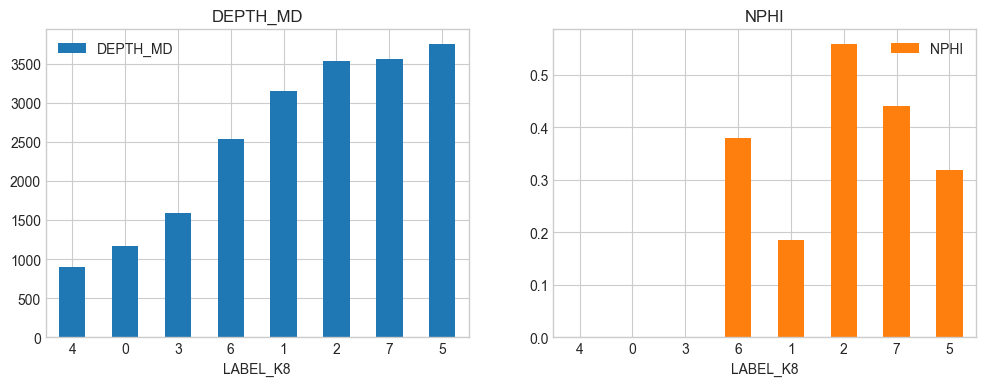

In [48]:
# Profiling berdasarkan median untuk semua variabel numerik
profiling_result = well_2527_copy.select_dtypes('number').groupby('LABEL_K8').median()

# Urutkan berdasarkan kedalaman
profiling_result.sort_values(by='DEPTH_MD', inplace=True)
print(profiling_result[['DEPTH_MD','NPHI']])

# Visualisasi ringkas
profiling_result[['DEPTH_MD','NPHI']].plot(kind='bar', subplots=True, layout=(1,2), figsize=(12,4), rot=0)

Eksplor berdasarkan range

In [49]:
# Ringkasan statistik per cluster
summary = well_2527_copy.select_dtypes('number').groupby('LABEL_K8').agg(['mean','median','min','max'])
summary[['DEPTH_MD','NPHI']]

DEPTH_MD                             NPHI                   
             mean   median      min      max  mean median   min   max
LABEL_K8                                                             
0        1167.199 1165.538  204.594 2189.258 0.000  0.000 0.000 0.000
1        3160.338 3146.402 2219.962 4005.810 0.176  0.185 0.027 0.377
2        3509.074 3529.290 3468.490 3529.442 0.397  0.558 0.071 0.560
3        1553.251 1584.906  230.434 1799.530 0.000  0.000 0.000 0.000
4         888.838  905.086  751.642 1052.298 0.000  0.000 0.000 0.000
5        3662.665 3749.310 3229.698 4019.490 0.321  0.318 0.155 0.447
6        2703.447 2531.106 2192.602 3760.482 0.377  0.380 0.182 0.604
7        3545.645 3558.626 3414.226 3626.266 0.386  0.441 0.080 0.636

---

## 🔹 K-Medoids / Partitioning Around Medoids (PAM)

Setelah kita memahami dan mempraktikkan metode **K-Means**, ada satu pertanyaan penting yang sering muncul:

👉 *“Bagaimana kalau data kita memiliki **outlier** atau nilai ekstrim, apakah K-Means tetap bekerja dengan baik?”*

Jawabannya: **tidak selalu.**
K-Means menggunakan *mean* sebagai pusat cluster (*centroid*), sehingga ketika ada **outlier**, posisi centroid bisa “tertarik” ke arah data ekstrim tersebut. Akibatnya, hasil clustering bisa menjadi kurang representatif.

Untuk mengatasi kelemahan ini, kita bisa beralih ke metode yang masih “keluarga dekat” dengan K-Means, yaitu **K-Medoids (atau Partitioning Around Medoids / PAM)**.

### 📌 Apa itu K-Medoids?

* Sama seperti K-Means, tujuannya adalah mengelompokkan data ke dalam **k cluster**.
* Bedanya, pusat cluster di K-Medoids bukan dihitung dari rata-rata (mean), melainkan dipilih dari **salah satu data asli** yang disebut **medoid**.
* Karena menggunakan medoid (data nyata), metode ini lebih **tahan terhadap outlier** dan bisa bekerja lebih baik pada data dengan kombinasi numerik maupun kategorikal.

### 🧩 Perbedaan K-Means vs K-Medoids

| Aspek                         | K-Means                      | K-Medoids                                     |
| ----------------------------- | ---------------------------- | --------------------------------------------- |
| Pusat cluster                 | Centroid (nilai rata-rata)   | Medoid (salah satu titik data)                |
| Sensitivitas terhadap outlier | Tinggi 🚨                    | Rendah ✅                                      |
| Jenis data                    | Numerik (Euclidean distance) | Numerik & Kategorikal (dengan Gower distance) |


### ⚙️ Bagaimana Cara Kerja K-Medoids?

1. Pilih sejumlah medoid awal secara acak.
2. Hitung jarak setiap data ke medoid terdekat.
3. Jika ada titik data yang bisa menjadi medoid baru (dan menurunkan total jarak), maka **tukar posisi medoid**.
4. Ulangi langkah 2–3 sampai posisi medoid tidak berubah lagi.

Secara matematis:

$$
S = b - a
$$

* `a` = total jarak objek ke medoid lama
* `b` = total jarak objek ke medoid baru
  Jika `S < 0`, maka lakukan pergantian medoid.

### 📊 Mengukur Jarak pada K-Medoids

Pada K-Means kita menggunakan **Euclidean Distance**.
Namun, K-Medoids lebih fleksibel, terutama ketika data kita berupa campuran numerik + kategorikal.

➡️ Solusi: gunakan **Gower Distance**

* Bisa menghitung jarak untuk data numerik, kategorikal, maupun campuran.
* Sudah tersedia di Python lewat library `gower`.

Contoh:

Metode Gower Distance tersimpan pada `library gower` dan fungsi yang dapat digunakan adalah `gower_matrix()`.

In [52]:
import gower

In [53]:
# Dataset
df = pd.DataFrame({
    'Age': [22, 33, 52, 46],
    'Gender': ['M', 'M', 'F', 'M'],
    'IQ': [111, 96, 102, 100],
    'Politics': ['Liberal', 'Moderate', 'Liberal', 'Moderate']
})
df

,Age,Gender,IQ,Politics
0,22,M,111,Liberal
1,33,M,96,Moderate
2,52,F,102,Liberal
3,46,M,100,Moderate


In [55]:
# Hitung jarak Gower
gower_dist = gower.gower_matrix(df)
gower_dist

array([[0.        , 0.5916667 , 0.65000004, 0.6333334 ],
       [0.5916667 , 0.        , 0.7583333 , 0.17500001],
       [0.65000004, 0.7583333 , 0.        , 0.5833333 ],
       [0.6333334 , 0.17500001, 0.5833333 , 0.        ]], dtype=float32)

In [56]:
# Tampilkan hasil dalam bentuk dataframe
pd.DataFrame(gower_dist, columns=df.index, index=df.index)

,0,1,2,3
0,0.000,0.592,0.650,0.633
1,0.592,0.000,0.758,0.175
2,0.650,0.758,0.000,0.583
3,0.633,0.175,0.583,0.000


**Implementasi pada data `well_num_scaled`**

In [58]:
# Hitung jarak antar observasi dengan Gower Distance
well2527_gower = gower.gower_matrix(well_num_scaled)
well2527_gower

array([[0.        , 0.0271685 , 0.03427067, ..., 0.2550752 , 0.26162818,
        0.2537523 ],
       [0.0271685 , 0.        , 0.00847728, ..., 0.2548315 , 0.26137522,
        0.25349915],
       [0.03427067, 0.00847728, 0.        , ..., 0.26094633, 0.26749006,
        0.259614  ],
       ...,
       [0.2550752 , 0.2548315 , 0.26094633, ..., 0.        , 0.00923915,
        0.00958056],
       [0.26162818, 0.26137522, 0.26749006, ..., 0.00923915, 0.        ,
        0.01266373],
       [0.2537523 , 0.25349915, 0.259614  , ..., 0.00958056, 0.01266373,
        0.        ]], dtype=float32)

### 📝 Catatan Penting

* Jika data **murni numerik**, sebenarnya Euclidean masih bisa dipakai.
* Jika ada campuran kategorikal (misalnya formasi batuan dengan label tertentu), **Gower Distance** lebih disarankan.
* Karena K-Medoids menggunakan medoid (salah satu data aktual), hasilnya biasanya lebih **stabil dan robust** dibanding K-Means.

---

### 📊 *Modelling* dengan K-Medoids

Pada **K-Means**, kita sudah belajar bagaimana menentukan jumlah cluster `k` yang optimum.
Prinsip yang sama juga berlaku pada **K-Medoids**:

* Bisa berdasarkan **kebutuhan bisnis**
* Bisa juga menggunakan pendekatan **visualisasi elbow plot**.

#### 🔎 1. Menentukan Jumlah Cluster dengan *Elbow Plot*

Kita buat visualisasi elbow plot dari matriks jarak **Gower Distance** untuk memilih jumlah cluster terbaik.

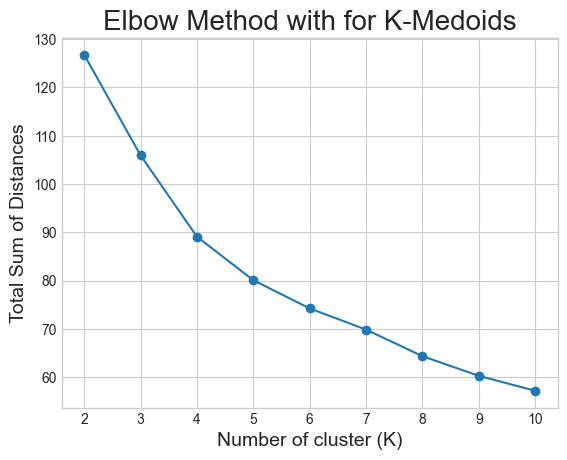

In [59]:
# Elbow method untuk K-Medoids
plot_elbow_kmedoids(well2527_gower)

📌 Dari grafik elbow terlihat bahwa titik “patah” terjadi pada **k = ...**, sehingga jumlah cluster yang optimum adalah **... cluster**.

#### ⚙️ 2. Pemodelan dengan K-Medoids

Sekarang kita bisa membentuk model K-Medoids dengan parameter:

* `n_clusters` : jumlah cluster
* `method` : gunakan `"pam"`
* `metric` : `"precomputed"` (karena kita sudah hitung jarak dengan Gower)
* `random_state` : untuk memastikan hasil konsisten (gunakan `123`)

Setelah fungsi tersebut terisi akan kita gabungkan dengan fungsi `.fit()` dengan random_state = 123.

In [60]:
from sklearn_extra.cluster import KMedoids

#Model Initialization
kmed_lith = KMedoids(n_clusters=8,method='pam',metric='precomputed' ,random_state=123)

In [61]:
# Fitting Model
kmed_lith.fit(well2527_gower)

KMedoids(method='pam', metric='precomputed', random_state=123)

📌 Untuk melihat label hasil pengelompokan, kita dapat menggunakan  attribute `.labels_` 

In [64]:
# label hasil clustering
label_kmed = kmed_lith.labels_

# tampilkan 10 label pertama
label_kmed[:10]

array([6, 6, 6, 6, 6, 6, 6, 6, 6, 6], dtype=int64)

#### 📍 3. Medoid vs Centroid

Karena kita menggunakan **precomputed distance**, informasi tentang titik pusat cluster (medoid) tidak langsung tersedia.

Namun, kita bisa mengaksesnya melalui atribut `.medoid_indices_`:

In [67]:
# Mendapatkan indeks medoid
medoid_indices = kmed_lith.medoids_indices_
print("Indeks medoid di data asli:", medoid_indices)

AttributeError: 'KMedoids' object has no attribute 'medoids_indices_'

💡 *Perbedaan dengan K-Means:*

* **K-Means** punya *centroid* (hasil rata-rata, bisa berupa titik imajiner).
* **K-Medoids** punya *medoid* (salah satu data nyata di dalam cluster).

#### 📈 4. Evaluasi Goodness of Fit

Seperti di K-Means, kita bisa menghitung **Within-Cluster Sum of Squares (WSS)**, **Between-Cluster Sum of Squares (BSS)**, dan **Total Sum of Squares (TSS)**, lalu menghitung **Explained Variance (EV)**.

In [ ]:
# WSS
WSS = 
print('WSS K Medoids:', WSS)

In [ ]:
# Menghitung centroid global
global_centroid = np.mean(well2527_gower[medoid_indices, :], axis=0)

# Menghitung BSS
BSS = 0
for medoid_index in medoid_indices:
    BSS += np.sum(well2527_gower[medoid_index, :] - global_centroid) ** 2
    
print('BSS K Medoids:', BSS)s

NameError: name 'medoid_indices' is not defined

In [ ]:
# TSS
TSS = 
print('TSS K Medoids:', TSS)

In [ ]:
# Explained variance (bss/tss)
EV = 
print('Explained Variance K medoids:', EV)

> 📌 Hasil: dengan **8 cluster**, metode K-Medoids berhasil menjelaskan informasi data sebesar **...**. 🚀

#### 🏷️ 5. Melabeli Dataframe dengan Hasil K-Medoids

Terakhir, kita tambahkan hasil label cluster ke dataframe asli untuk keperluan **profiling**.

In [ ]:
# assign label from K-medoids with 8 clusters
well_2527_copy['LABEL_KMED8'] = 

#### 🧩 *6. Cluster Profiling*

Tahap terakhir dari proses *clustering* adalah **profiling**, yaitu memahami karakteristik dari masing-masing cluster yang sudah terbentuk. Tujuannya:

* 🔎 Mengetahui apa yang membedakan tiap cluster
* 📝 Memberi interpretasi praktis agar hasil clustering bisa dipakai dalam pengambilan keputusan

👉 Dalam konteks ini, kita akan menganalisis cluster berdasarkan **kedalaman (DEPTH_MD)** dan **porositas neutron (NPHI)** yang diperoleh dari data logging sumur.

##### ⛏️ Profiling Berdasarkan Kedalaman (DEPTH_MD)

Kedalaman (`DEPTH_MD`) penting untuk melihat di lapisan mana masing-masing cluster terbentuk.

In [ ]:
# Profiling dari kedalaman
well_2527_copy

🔎 Urutan median kedalaman tiap cluster:

* **Cluster 0** → ......
* **Cluster 1** → ......
* **Cluster 2** → ......
* **Cluster 3** → ......
* **Cluster 4** → ......
* **Cluster 5** → ......
* **Cluster 6** → ......
* **Cluster 7** → ......

👉 Artinya: cluster membagi data sumur dari .....**.

##### 🛢️ Profiling Berdasarkan Porositas Neutron (NPHI)

Selanjutnya, mari kita analisis cluster berdasarkan `NPHI` (Neutron Porosity). Variabel ini penting karena menunjukkan **kandungan hidrogen**, yang sering dipakai untuk menilai potensi reservoir minyak atau gas.

In [ ]:
# Profiling berdasarkan NPHI
well_2527_copy

🔎 Urutan median porositas tiap cluster:

* **Cluster 0** → ......
* **Cluster 1** → ......
* **Cluster 2** → ......
* **Cluster 3** → ......
* **Cluster 4** → ......
* **Cluster 5** → ......
* **Cluster 6** → ......
* **Cluster 7** → ......

👉 Artinya: ada pola menarik bahwa .....

# Glossary

- *Variance*: Ukuran seberapa jauh sebuah kumpulan bilangan tersebar. Nilai variance yang mendekati 0 menunjukkan data tidak banyak beragam. 
- *Std (Standard Deviation)*: Akar kuadrat dari variance, dapat digunakan untuk menentukan keragaman data. Semakin kecil nilai *Std* maka data semakin tidak beragam dan sebaliknya.
- *Covariance*: Nilai yang menunjukkan hubungan antara variansi pada variable $X$ dan variansi pada variable $Y$. Tidak dapat di interpretasikan, dikarenakan memiliki nilai negatif tak hingga sampai positif tak hingga.
- *Correlation*: Nilai yang menunjukkan hubungan antar variable $X$ dengan variable $Y$. Memiliki rentang nilai -1 sampai 1. Nilai korelasi mendekati 1 menujukkan variable $X$ dan $Y$ memiliki hubungan positif kuat, sedangkan nilai korelasi mendekati -1 menunjukkan variable $X$ dan $Y$ memiliki hubungan negatif kuat.

# Referensi

- [In Depth: Principal Component Analysis (Jake VanderPlas)](https://jakevdp.github.io/PythonDataScienceHandbook/05.09-principal-component-analysis.html)
- [Intuisi PCA](https://stats.stackexchange.com/questions/2691/making-sense-of-principal-component-analysis-eigenvectors-eigenvalues/2700#2700)
- [PCA (chapter 3)](https://ourarchive.otago.ac.nz/bitstream/handle/10523/7534/OUCS-2002-12.pdf?sequence=1&isAllowed=y)
- [The Importance of Feature Scaling before PCA](https://scikit-learn.org/stable/auto_examples/preprocessing/plot_scaling_importance.html)